In [1]:
import anndata as ad
import scanpy as sc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
from clustering import protein_clustering, cluster_genes, cluster_proteins

In [3]:
# import preprocessed data
rna_pr = ad.read_h5ad("../../../data/rna_train_preprocessed.h5ad")
pro_pr = ad.read_h5ad("../../../data/pro_train_preprocessed.h5ad")
valid_rna_pr = ad.read_h5ad("../../../data/rna_val_preprocessed.h5ad")

# Leiden clustering - spatial map, UMAP plot and dot plot

/Users/emilybeermann/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Leiden resolution: 0.2, Number of clusters: 6
Clusters: protein_cluster
2    57718
4    46764
0    31811
1    21691
3     8174
5       28
Name: count, dtype: int64


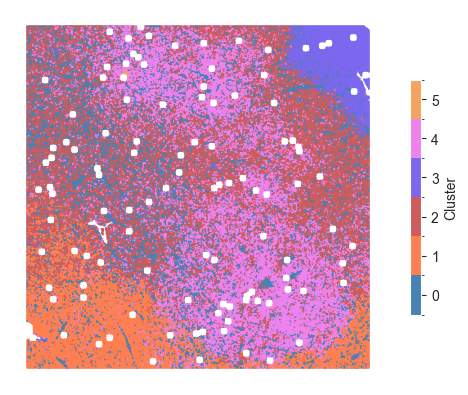

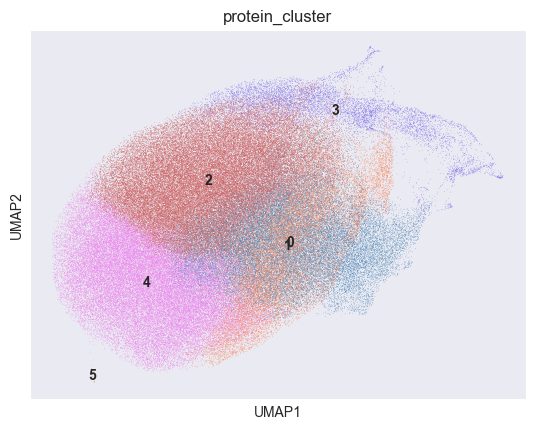

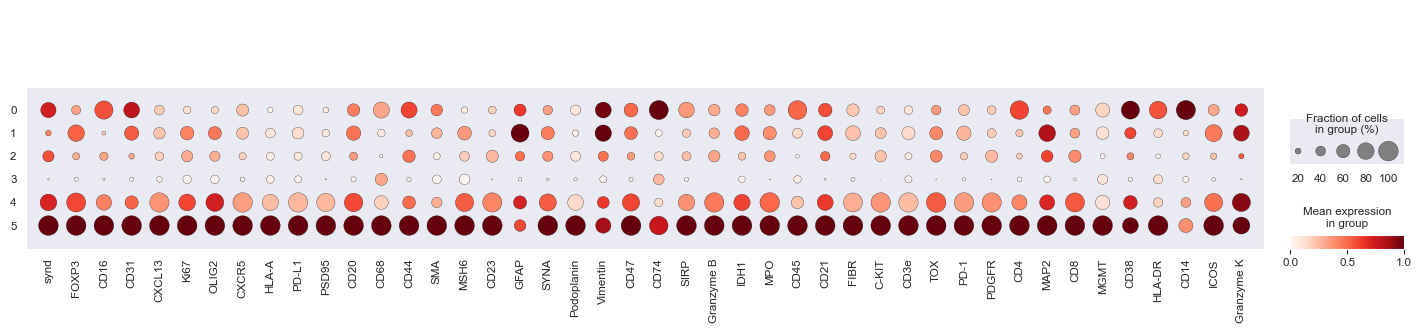

In [4]:
# stage 1
protein_data = protein_clustering(pro_pr, 0.2)

In [7]:
protein_data.write_h5ad("results/pro_cl0.5.h5ad")

# Add cluster labels to RNA, Find marker genes per cluster

In [8]:
# find marker genes
rna_hvg, markers_df = cluster_genes(rna_pr, protein_data, 5)
markers_df

,cluster,rank,gene,score,log2FC,pval_adj
0,0,1,SELENOP,47.005699,1.5375,0.00e+00
1,0,2,CD74,41.639198,1.1612,0.00e+00
2,0,3,A2M,37.242599,1.3460,9.29e-301
3,0,4,C1QA,22.742201,1.0469,8.56e-112
4,0,5,SLC40A1,21.813200,1.1725,6.96e-103
5,1,1,IGFBP5,21.750799,1.2049,1.36e-101
6,1,2,IGHM,18.773199,4.5395,1.25e-75
7,1,3,EGR1,17.353300,1.5553,1.24e-64
8,1,4,IGKC,16.048401,3.7510,2.93e-55
9,1,5,SOX5,15.966100,1.1166,8.80e-55


In [9]:
# save files
rna_hvg.write_h5ad("results/rna_hvg_cl0.5.h5ad")
markers_df.to_csv("results/genes_cl0.5.csv")

# Find proteins per cluster

In [5]:
protein_clustered, protein_markers_df = cluster_proteins(protein_data, n_markers=3)
protein_markers_df

/Users/emilybeermann/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/emilybeermann/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/emilybeermann/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/emilybeermann/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/emilybeermann/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.st

,cluster,rank,protein,score,log2FC,pval_adj
0,0,1,CD14,248.667206,NaN,0.00e+00
1,0,2,CD74,226.957397,NaN,0.00e+00
2,0,3,CD45,225.049805,NaN,0.00e+00
3,1,1,GFAP,132.274002,NaN,0.00e+00
4,1,2,MAP2,118.269600,NaN,0.00e+00
5,1,3,ICOS,101.598801,NaN,0.00e+00
6,2,1,CD44,8.987800,NaN,2.52e-19
7,2,2,Podoplanin,-23.193600,NaN,5.40e-119
8,2,3,CD23,-26.734100,NaN,1.98e-157
9,3,1,CD68,24.936899,NaN,3.18e-137
